<a href="https://colab.research.google.com/github/senseiK2/IA-et-Objet-Connect-s/blob/main/%20%20%20TP1_MNIST/ETRS923_TP1_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETRS923 – TP1 : Problème MNIST
**Master ESET – Université Savoie Mont Blanc**

## Étape 1 : Chargement et préparation des données
Chaque image [28×28] est aplatie en un vecteur [1×784], normalisée dans [0,1].
Les labels sont encodés en one-hot pour `categorical_crossentropy`.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

import os
DOSSIER = "/content/drive/MyDrive/ETRS923/TP1"
os.makedirs(DOSSIER, exist_ok=True)
print("Dossier de travail :", DOSSIER)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dossier de travail : /content/drive/MyDrive/ETRS923/TP1


Brut   : (60000, 28, 28) (60000,) (10000, 28, 28)
Aplati : (60000, 784) (10000, 784)
Label 0 -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


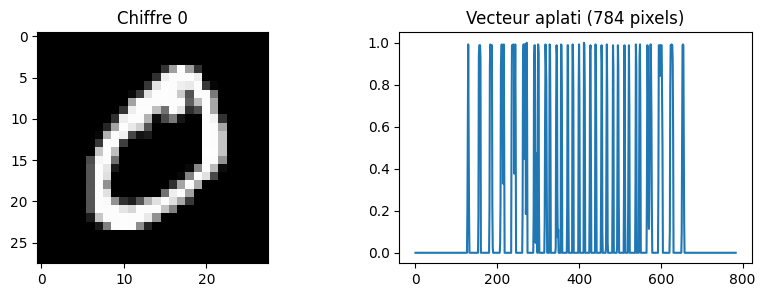

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)

# 1. Chargement
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Brut   :", x_train.shape, y_train.shape, x_test.shape) # TD (images), correction du TD, examen (images) ; y_test = correction de l'examen, cachée au réseau pour le noter

# 2. Aplatissement 28x28 -> 784 et normalisation [0,255] -> [0,1]
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.0
print("Aplati :", x_train.shape, x_test.shape)

# 3. Labels one-hot (pour categorical_crossentropy, imposée en partie 1)
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)
print("Label", y_train[1], "->", y_train_oh[1])

# 4. Vérification visuelle : l'image et son vecteur de 784 pixels
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(x_train[1].reshape(28, 28), cmap="gray"); ax[0].set_title(f"Chiffre {y_train[1]}")
ax[1].plot(x_train[1]); ax[1].set_title("Vecteur aplati (784 pixels)")
plt.show()